# Lab 5: 规划与协调层 — Planning & Coordination

对应 Harness 六层架构：第 ❺ 层

## 学习目标

- 理解 **Team Lead 协调模式** — 主 agent 分派子任务给子 agent
- 实现 `AgentTool`：让 agent 可以"分身"，生成拥有独立 context 的子 agent
- 实现任务管理系统：创建、跟踪、完成子任务
- 理解子 agent **独立 context** 为什么重要

## 痛点回顾

Lab 4 的 agent 有了安全拦截层。但面对复杂的多步骤任务时：
- 只能串行处理，一个接一个
- 所有子任务的上下文挤在同一个 context window 中
- 无法并行或分而治之

**本 Lab 的目标：让 agent 学会"分身术"和"团队协作"。**

## 对应 Claude Code 源码

- `tools/AgentTool/` — 子 agent 生成工具
- `tools/TeamCreateTool/` — 团队创建
- `tools/TaskCreateTool/` — 任务创建
- `tools/SendMessageTool/` — Agent 间通信
- `coordinator/` — 多 agent 协调模式

Claude Code 的多 agent 架构：

```
Team Lead (主 agent)
  ├── TaskCreate    → 拆分子任务
  ├── AgentTool     → 生成子 agent（独立 context）
  ├── SendMessage   → agent 间通信
  └── TaskUpdate    → 跟踪任务状态

Sub-Agent (子 agent)
  ├── 拥有基础工具（read/write/bash）
  ├── 独立的 messages 历史
  ├── 有限的轮数（防止失控）
  └── 完成后返回结果给主 agent
```


---
## 第一步：环境准备 + 回顾 Lab 2-4 代码

In [1]:
# === Environment prep + Lab 2-4 recap ===
from utils.llm import create_harness_client, default_model

client = create_harness_client()
MODEL = default_model()


# --- Core tools from Lab 2 ---
from utils.tools import WriteFileTool,ReadFileTool,BashTool,Tool, EditFileTool,clean_cache_control
# --- Permission system preview from Lab 3 ---
from utils.permissions import SmartPermissionChecker


BASE_TOOLS = [ReadFileTool(), WriteFileTool(), BashTool(),EditFileTool()]
checker = SmartPermissionChecker()
print(f"Lab 2-4 recap ready. Base tools: {len(BASE_TOOLS)}")


Lab 2-4 recap ready. Base tools: 4


---
## 第二步：构建子 Agent 运行器 （支持并行工具调用）

在实现 `AgentTool` 之前，我们先抽取一个通用的 agent 运行函数。

这个函数将被主 agent 和子 agent 共用——子 agent 就是一个运行在独立 context 中的 agent loop。

Claude 可以在一次响应中返回多个 tool_use 块，这些工具之间如果互不依赖，可以并行执行以提升效率。

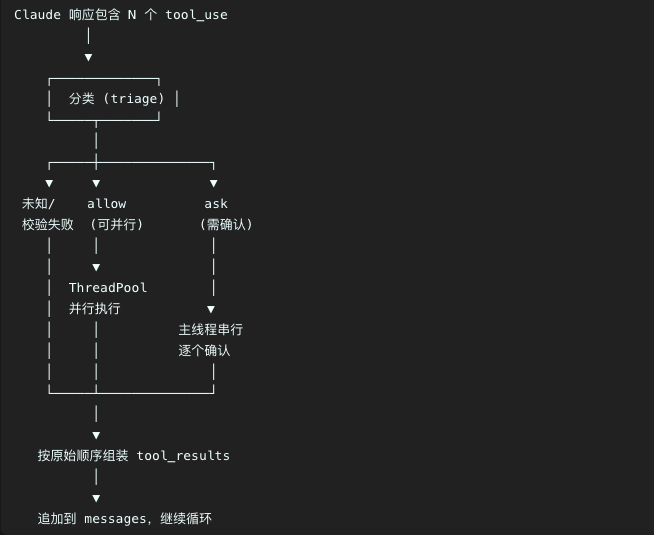

In [2]:
import concurrent.futures
from threading import Lock

def run_agent_loop(system_prompt, tools_list, user_messages,
              max_turns=20, hooks_runner=None, permission_checker=None,
              context_manager=None, max_workers=5):
    """通用 Agent 运行器（消息列表驱动）。支持并行工具调用。"""

    def _serialize_content(content_blocks):
        """将 SDK ContentBlock 序列化为纯 dict 列表"""
        result = []
        for blk in content_blocks:
            if hasattr(blk, 'type'):
                if blk.type == 'text':
                    result.append({'type': 'text', 'text': blk.text})
                elif blk.type == 'tool_use':
                    result.append({'type': 'tool_use', 'id': blk.id, 'name': blk.name, 'input': blk.input})
                elif blk.type == 'thinking':
                    d = {'type': 'thinking', 'thinking': blk.thinking}
                    if hasattr(blk, 'signature') and blk.signature:
                        d['signature'] = blk.signature
                    result.append(d)
                elif blk.type == 'redacted_thinking':
                    result.append({'type': 'redacted_thinking', 'data': blk.data})
                else:
                    result.append({'type': blk.type})
            elif isinstance(blk, dict):
                result.append(blk)
        return result

    def _execute_single_tool(blk, tool):
        """
        执行单个工具调用，返回 (tool_use_id, result, is_error)。
        需要用户交互的（ask）不能并行，会在主线程单独处理。
        """
        # 参数校验
        validation_error = tool.validate(blk.input)
        if validation_error:
            return blk.id, f"参数校验失败: {validation_error}", True

        # Pre-hook
        inp = hooks_runner.run_pre_tool(blk.name, blk.input) if hooks_runner else blk.input
        if inp is None:
            return blk.id, "被 Hook 阻止", True

        # 权限检查（deny 可以在线程中直接处理）
        perm = permission_checker.check(blk.name, blk.input) if permission_checker else "allow"

        if perm == "deny":
            print(f"\n  🚫 [拒绝] {blk.name}({blk.input})")
            return blk.id, "权限拒绝：此操作已被禁止。", True

        if perm == "ask":
            # 标记需要主线程交互，返回特殊标志
            return blk.id, "__NEEDS_CONFIRMATION__", None

        # allow → 执行
        result = tool.execute(blk.input)
        if hooks_runner:
            result = hooks_runner.run_post_tool(blk.name, inp, result)
        return blk.id, result, False

    def _handle_confirmation(blk, tool):
        """主线程中处理需要用户确认的工具调用"""
        print(f"\n  ⚠️  [需要确认] {blk.name}")
        print(f"     参数: {blk.input}")
        confirm = input("     允许执行？(y/n): ")
        if confirm.strip().lower() in ("y", "yes"):
            inp = hooks_runner.run_pre_tool(blk.name, blk.input) if hooks_runner else blk.input
            result = tool.execute(blk.input)
            if hooks_runner and inp:
                result = hooks_runner.run_post_tool(blk.name, inp, result)
            print(f"     ✅ 已执行")
            return blk.id, result, False
        else:
            print(f"     ❌ 用户拒绝")
            return blk.id, "用户拒绝了此操作。", True

    def _process_tool_calls(tool_blocks):
        """
        处理所有 tool_use 块，自动判断是否可以并行。
        返回: 按原始顺序排列的 [(tool_use_id, result, is_error), ...]
        """
        if not tool_blocks:
            return []

        # 只有1个工具调用，直接串行
        if len(tool_blocks) == 1:
            blk = tool_blocks[0]
            tool = _tool_map.get(blk.name)
            if tool is None:
                return [(blk.id, f"未知工具 {blk.name}", True)]
            tid, res, err = _execute_single_tool(blk, tool)
            if res == "__NEEDS_CONFIRMATION__":
                return [_handle_confirmation(blk, tool)]
            return [(tid, res, err)]

        # 多个工具调用 → 并行执行
        # 第一步：分类 —— 已知/未知、是否需要确认
        results_map = {}  # blk.id → (result, is_error)
        parallel_tasks = []  # (blk, tool)
        confirmation_tasks = []  # (blk, tool) 需要主线程交互的

        for blk in tool_blocks:
            tool = _tool_map.get(blk.name)
            if tool is None:
                results_map[blk.id] = (f"未知工具 {blk.name}", True)
            else:
                # 预检权限，分流
                validation_error = tool.validate(blk.input)
                if validation_error:
                    results_map[blk.id] = (f"参数校验失败: {validation_error}", True)
                    continue

                perm = permission_checker.check(blk.name, blk.input) if permission_checker else "allow"
                if perm == "deny":
                    results_map[blk.id] = ("权限拒绝：此操作已被禁止。", True)
                    print(f"\n  🚫 [拒绝] {blk.name}({blk.input})")
                elif perm == "ask":
                    confirmation_tasks.append((blk, tool))
                else:
                    parallel_tasks.append((blk, tool))

        # 第二步：并行执行 allow 的任务
        if parallel_tasks:
            with concurrent.futures.ThreadPoolExecutor(max_workers=min(max_workers, len(parallel_tasks))) as executor:
                future_map = {}
                for blk, tool in parallel_tasks:
                    future = executor.submit(_run_tool_safe, blk, tool, hooks_runner)
                    future_map[future] = blk

                for future in concurrent.futures.as_completed(future_map):
                    blk = future_map[future]
                    try:
                        result, is_error = future.result()
                    except Exception as e:
                        result, is_error = f"工具执行异常: {e}", True
                    results_map[blk.id] = (result, is_error)

        # 第三步：串行处理需要确认的（用户交互不能并行）
        for blk, tool in confirmation_tasks:
            tid, res, err = _handle_confirmation(blk, tool)
            results_map[tid] = (res, err)

        # 第四步：按原始顺序返回
        ordered = []
        for blk in tool_blocks:
            res, err = results_map[blk.id]
            ordered.append((blk.id, res, err))
        return ordered

    def _run_tool_safe(blk, tool, hooks_runner):
        """线程安全的工具执行"""
        inp = hooks_runner.run_pre_tool(blk.name, blk.input) if hooks_runner else blk.input
        if inp is None:
            return "被 Hook 阻止", True
        result = tool.execute(blk.input)
        if hooks_runner:
            result = hooks_runner.run_post_tool(blk.name, inp, result)
        return result, False

    # ============ 主循环 ============

    _tool_map = {t.name: t for t in tools_list}
    _tools_schema = [t.to_api_schema() for t in tools_list]
    messages = []
    last_text = ""
    msg_index = 0

    for turn in range(1, max_turns + 1):
        if msg_index >= len(user_messages):
            break
        user_input = user_messages[msg_index]
        msg_index += 1

        messages.append({"role": "user", "content": user_input})

        # 上下文压缩检查
        if context_manager and context_manager.should_compact(messages):
            messages = context_manager.compact(messages)
            print("  [Compaction] 上下文已压缩")

        while True:
            # 清理多余的 cache_control
            messages = clean_cache_control(messages)

            with client.messages.stream(
                model=MODEL,
                max_tokens=32000,
                system=system_prompt,
                tools=_tools_schema,
                messages=messages,
                thinking={"type": "adaptive"},
            ) as stream:
                print(f'\nAssistant: ', end='', flush=True)
                for text in stream.text_stream:
                    print(text, end='', flush=True)
                print()
                response = stream.get_final_message()
            messages.append({"role": "assistant", "content": _serialize_content(response.content)})

            # ---- 收集本轮所有 tool_use 块 ----
            tool_blocks = []
            for blk in response.content:
                if blk.type == "text":
                    last_text = blk.text
                elif blk.type == "tool_use":
                    tool_blocks.append(blk)

            if not tool_blocks:
                # 无工具调用，本轮结束
                break

            # ---- 并行/串行执行工具 ----
            n_tools = len(tool_blocks)
            if n_tools > 1:
                print(f"\n  ⚡ 并行执行 {n_tools} 个工具调用")

            exec_results = _process_tool_calls(tool_blocks)

            # ---- 构建 tool_results ----
            tool_results = []
            for (tool_use_id, result, is_error), blk in zip(exec_results, tool_blocks):
                print(f"  [{blk.name}] {str(blk.input)[:80]}")
                print(f"   -> {str(result)[:300]}")
                tool_results.append({
                    "type": "tool_result",
                    "tool_use_id": tool_use_id,
                    "cache_control": {"type": "ephemeral"},
                    "content": result,
                    **({"is_error": True} if is_error else {}),
                })

            if tool_results:
                messages.append({"role": "user", "content": tool_results})

            if response.stop_reason == "max_tokens":
                # token 耗尽（可能截断了 tool_use），继续循环让模型重试
                print("  [warn] max_tokens reached, continuing...")
                continue
            if response.stop_reason != "tool_use":
                break

    return last_text

---
## 第三步：实现 AgentTool — 子 Agent 生成器

这是多 agent 系统的核心：**让 agent 可以"分身"**。

当主 agent 调用 `dispatch_agent` 工具时：
1. 创建一个新的 `run_agent()` 实例
2. 给它传入任务描述作为 initial_message
3. 它拥有**独立的 messages 列表**（独立 context）
4. 它只能使用基础工具（**不能再分身**，防止递归）
5. 有最大轮数限制（防止失控）
6. 执行完毕后，将结果返回给主 agent

这对应 Claude Code 中的 `AgentTool`。

In [3]:
# AgentTool: 子 Agent 生成器（对应 Claude Code 的 tools/AgentTool/）
import os
from utils.project_memory import ProjectMemory

class AgentTool(Tool):
    """生成子 agent 来处理子任务。子 agent 拥有独立的 context。"""

    def __init__(self, base_tools):
        self._base_tools = base_tools

    @property
    def name(self): return "dispatch_agent"

    @property
    def description(self):
        return "派遣一个子 agent 来独立完成一个具体的子任务。子 agent 拥有独立的上下文。请提供子Agent清晰具体的任务描述。"

    @property
    def input_schema(self):
        return {
            "type": "object",
            "properties": {
                "name":{"type": "string", "description": "子agent 的名称"},
                "prompt": {"type": "string", "description": "要派发给子 agent 的具体任务描述"},
            },
            "required": ["name","prompt"],
        }

    def execute(self,tool_input):
        task = tool_input["prompt"]
        print(f"\n  子Agent:{tool_input['name']} 启动: {task[:80]}...")

        sub_prompt = f"{task}"

        # ❶ 项目记忆注入
        pm = ProjectMemory()
        full_prompt = pm.build_system_prompt(sub_prompt, os.getcwd())

        # 子 agent 用消息列表驱动（单条任务消息）
        result = run_agent_loop(
            system_prompt=full_prompt,
            tools_list=self._base_tools,
            user_messages=[task],
            max_turns=50,
        )

        print(f"  子Agent:{tool_input['name']}: {result[:100]}...")
        return result

print("AgentTool 就绪")


AgentTool 就绪


---
## 第四步：实现任务管理系统

Claude Code 中，Team Lead 使用任务系统来：
1. **拆分** — 把复杂任务拆成可独立执行的子任务
2. **跟踪** — 查看哪些任务完成了，哪些还在进行
3. **协调** — 确保子任务之间的依赖关系得到满足

我们实现一个简化版的 `TaskCreate` 和 `TaskList`。

In [4]:
# 任务管理器（对应 Claude Code 的 TaskCreateTool / TaskListTool）

class TaskManager:
    """简单的任务管理系统。"""
    
    def __init__(self):
        self._tasks: dict[str, dict] = {}
        self._counter = 0
    
    def create(self, subject: str, description: str = "") -> str:
        self._counter += 1
        task_id = str(self._counter)
        self._tasks[task_id] = {
            "subject": subject,
            "description": description,
            "status": "pending",
        }
        return task_id
    
    def update(self, task_id: str, status: str):
        if task_id in self._tasks:
            self._tasks[task_id]["status"] = status
    
    def list_all(self) -> list[dict]:
        return [{"id": k, **v} for k, v in self._tasks.items()]

# 全局任务管理器实例
task_mgr = TaskManager()

# 任务创建工具
class TaskCreateTool(Tool):
    @property
    def name(self): return "create_task"
    @property
    def description(self): return "创建一个子任务来跟踪工作进度"
    @property
    def input_schema(self):
        return {
            "type": "object",
            "properties": {
                "subject": {"type": "string", "description": "任务标题"},
                "description": {"type": "string", "description": "任务详情"},
            },
            "required": ["subject"],
        }
    def execute(self, tool_input):
        tid = task_mgr.create(tool_input["subject"], tool_input.get("description", ""))
        return f"任务 #{tid} 已创建: {tool_input['subject']}"

# 任务列表工具
class TaskListTool(Tool):
    @property
    def name(self): return "list_tasks"
    @property
    def description(self): return "列出所有任务及其状态"
    @property
    def input_schema(self):
        return {"type": "object", "properties": {}}
    def execute(self, tool_input):
        tasks = task_mgr.list_all()
        if not tasks:
            return "当前没有任务。"
        lines = []
        for t in tasks:
            icon = "✅" if t["status"] == "completed" else "⏳" if t["status"] == "in_progress" else "📋"
            lines.append(f"{icon} #{t['id']} [{t['status']}] {t['subject']}")
        return "\n".join(lines)

# 任务更新工具
class TaskUpdateTool(Tool):
    @property
    def name(self): return "update_task"
    @property
    def description(self): return "更新任务状态（pending → in_progress → completed）"
    @property
    def input_schema(self):
        return {
            "type": "object",
            "properties": {
                "task_id": {"type": "string", "description": "任务 ID"},
                "status": {"type": "string", "enum": ["pending", "in_progress", "completed"]},
            },
            "required": ["task_id", "status"],
        }
    def execute(self, tool_input):
        task_mgr.update(tool_input["task_id"], tool_input["status"])
        return f"任务 #{tool_input['task_id']} 状态已更新为 {tool_input['status']}"

print("✓ 任务管理工具就绪: create_task, list_tasks, update_task")

✓ 任务管理工具就绪: create_task, list_tasks, update_task


---
## 第四步（续）：实现 SendMessageTool — Agent 间通信

Claude Code 中，Team Lead 和子 Agent 之间通过 `SendMessageTool` 通信。
这是多 Agent 协作的关键基础设施：

- Team Lead 可以给子 Agent 发指令
- 子 Agent 可以向 Team Lead 汇报进度
- Agent 间通过共享的 **Mailbox（消息邮箱）** 交换消息

Claude Code 使用文件系统（`TeamFile` + `Mailbox`）实现 Agent 间通信。
我们用一个简化的内存 Mailbox 来演示。


In [5]:
# SendMessageTool: Agent 间通信（对应 Claude Code 的 SendMessageTool）

from datetime import datetime

class Mailbox:
    """Agent 间的消息邮箱。类似 Claude Code 中基于文件的 Mailbox 机制。"""
    def __init__(self):
        self._messages: list[dict] = []

    def send(self, sender: str, receiver: str, content: str):
        self._messages.append({
            'sender': sender,
            'receiver': receiver,
            'content': content,
            'time': datetime.now().isoformat(),
        })

    def receive(self, receiver: str) -> list[dict]:
        """获取发给指定 receiver 的所有未读消息"""
        msgs = [m for m in self._messages if m['receiver'] == receiver]
        # 取出后清除（模拟已读）
        self._messages = [m for m in self._messages if m['receiver'] != receiver]
        return msgs

    def all_messages(self) -> list[dict]:
        """查看全部消息历史（调试用）"""
        return list(self._messages)


# 全局邮箱实例
mailbox = Mailbox()


class SendMessageTool(Tool):
    """发送消息给其他 Agent。对应 Claude Code 的 SendMessageTool。"""

    @property
    def name(self): return "send_message"
    @property
    def description(self):
        return "发送消息给其他 agent。用于 Team Lead 与子 agent 之间的通信。"
    @property
    def input_schema(self):
        return {
            "type": "object",
            "properties": {
                "to": {"type": "string", "description": "接收者名称（如 team-lead, sub-agent-1）"},
                "message": {"type": "string", "description": "消息内容"},
            },
            "required": ["to", "message"],
        }

    def execute(self, tool_input):
        receiver = tool_input['to']
        content = tool_input['message']
        mailbox.send('agent', receiver, content)
        print(f'    [SendMessage] -> {receiver}: {content[:100]}')
        return f'消息已发送给 {receiver}'


# === 演示：Agent 间通信 ===
print('=== SendMessage 演示 ===')

# 模拟 Team Lead 给子 Agent 发任务
mailbox.send('team-lead', 'sub-agent-1', '请分析 lab1 的代码结构')
mailbox.send('team-lead', 'sub-agent-2', '请分析 lab2 的代码结构')

# 模拟子 Agent 回复
mailbox.send('sub-agent-1', 'team-lead', 'lab1 有 17 个 cell，主要实现提示引导层')

# Team Lead 查收消息
msgs = mailbox.receive('team-lead')
print(f'\nTeam Lead 收到 {len(msgs)} 条消息:')
for m in msgs:
    print(f'  来自 {m["sender"]}: {m["content"]}')

# 重置邮箱
mailbox = Mailbox()
print('\n✓ SendMessageTool + Mailbox 就绪')


=== SendMessage 演示 ===

Team Lead 收到 1 条消息:
  来自 sub-agent-1: lab1 有 17 个 cell，主要实现提示引导层

✓ SendMessageTool + Mailbox 就绪


---
## 第五步：组装Mini Harness

现在把所有组件拼在一起！

**关键设计：**
- 主 agent（Team Lead）拥有全部工具：基础工具 + AgentTool + 任务工具
- 子 agent 只拥有基础工具（不能再分身，防止递归）
- 主 agent 可以自主决定是否拆分任务、是否派遣子 agent

In [6]:
# 组装完整的 Mini Harness

# 基础工具（子 agent 可用）
base_tools = [ReadFileTool(), WriteFileTool(), BashTool(), EditFileTool(), SendMessageTool()]

# 主 agent 的完整工具集
all_tools = base_tools + [
    AgentTool(base_tools=base_tools),  # 子 agent 只能用基础工具
    TaskCreateTool(),
    TaskListTool(),
    TaskUpdateTool(),
]

print("=== Mini Harness 架构 ===")
print(f"\n主 Agent (Team Lead) 工具:")
for t in all_tools:
    print(f"  🔧 {t.name}")
print(f"\n子 Agent 工具:")
for t in base_tools:
    print(f"  🔧 {t.name}")
print(f"\n注意: 子 agent 没有 dispatch_agent 工具（防递归）")


=== Mini Harness 架构 ===

主 Agent (Team Lead) 工具:
  🔧 read_file
  🔧 write_file
  🔧 bash
  🔧 edit_file
  🔧 send_message
  🔧 dispatch_agent
  🔧 create_task
  🔧 list_tasks
  🔧 update_task

子 Agent 工具:
  🔧 read_file
  🔧 write_file
  🔧 bash
  🔧 edit_file
  🔧 send_message

注意: 子 agent 没有 dispatch_agent 工具（防递归）


---
## 第六步：验证运行

试试这个复杂任务，观察主 agent 如何拆分和协调：

> "分析当前目录下的所有 .ipynb 文件，报告每个文件的 cell 数量和主要内容摘要"

你应该能观察到：
1. 主 agent 创建任务计划
2. 主 agent 为每个文件派遣子 agent
3. 子 agent 独立分析各自的文件
4. 主 agent 汇总所有结果

In [7]:
# 运行完整的 Mini Harness

TEAM_LEAD_PROMPT = """你是一个 Team Lead Agent（团队负责人）。

你的工作方式：
1. 收到复杂任务时，先用 create_task 拆分为子任务
2. 用 dispatch_agent 派遣子 agent 来处理各个子任务
3. 用 update_task 跟踪任务进度
4. 最后汇总所有结果给用户

对于简单任务，你可以直接用基础工具自己完成。
用中文回答。"""

# 重置任务管理器
task_mgr = TaskManager()

print("=" * 60)
print("Lab 5: Mini Harness — Team Lead Agent")
print("=" * 60)

run_agent_loop(
    system_prompt=TEAM_LEAD_PROMPT,
    tools_list=all_tools,
    user_messages=[
        "分析当前目录下的所有 .ipynb 文件，生产主要内容摘要",
    ],
    permission_checker=checker,
)


Lab 5: Mini Harness — Team Lead Agent

Assistant: 我来帮您分析当前目录下的所有 .ipynb 文件并生成主要内容摘要。首先让我查看当前目录结构。
  [bash] {'command': 'pwd && ls -la'}
   -> /mnt/d/agent_harness_workshop/labs
total 416
drwxrwxrwx 1 ying ying   4096 Apr 15 21:35 .
drwxrwxrwx 1 ying ying   4096 Apr 15 21:38 ..
drwxrwxrwx 1 ying ying   4096 Apr 15 17:16 .ipynb_checkpoints
-rwxrwxrwx 1 ying ying    333 Apr 15 15:35 CLAUDE.md
drwxrwxrwx 1 ying ying   4096 Apr 15 15:35 gomoku

Assistant: 我看到当前目录下有多个 .ipynb 文件。让我创建一个任务来跟踪这个分析工作。
  [create_task] {'subject': '分析当前目录下的所有 .ipynb 文件', 'description': '分析 /mnt/d/agent_harness_work
   -> 任务 #1 已创建: 分析当前目录下的所有 .ipynb 文件

Assistant: 现在让我更新任务状态为进行中，并开始分析这些文件。
  [update_task] {'task_id': '1', 'status': 'in_progress'}
   -> 任务 #1 状态已更新为 in_progress

Assistant: 首先，让我查看一下这些 .ipynb 文件的基本信息：
  [bash] {'command': 'ls -lh *.ipynb'}
   -> Mode   LastWriteTime      Length Name                            
----   -------------      ------ ----                            
-a---- 2026/4/15 20:47:03

'## 当前目录下所有 .ipynb 文件主要内容摘要\n\n基于对6个Jupyter Notebook文件的分析，以下是每个文件的主要内容摘要：\n\n### 1. **lab1_prompt_guidance.ipynb** - 提示与引导层\n- **学习目标**：理解system prompt对agent行为的决定性影响，实现CLAUDE.md项目记忆自动发现与注入，实现Hooks生命周期钩子，建立Agent Loop基座\n- **核心内容**：Harness六层架构的第❶层，重点讲解如何通过系统提示词引导agent行为，建立项目记忆系统\n- **文件大小**：51,227字节\n\n### 2. **lab2_tool_execution.ipynb** - 工具与执行层\n- **学习目标**：理解统一工具接口设计模式，实现validation→execution→result的工具管道，让agent能够真正读写文件、执行命令\n- **核心内容**：Harness六层架构的第❷层，解决Lab 1中agent有工具意图但无法执行的问题\n- **文件大小**：36,901字节\n\n### 3. **lab3_safety_permission.ipynb** - 验证与安全层\n- **学习目标**：理解权限中间件模式，实现allow/deny/ask三级权限控制，实现简单的Bash命令安全分类器，理解HITL设计哲学\n- **核心内容**：Harness六层架构的第❸层（教学顺序调整），在工具执行前插入安全拦截层\n- **文件大小**：44,271字节\n\n### 4. **lab4_context_memory.ipynb** - 上下文与内存层\n- **学习目标**：理解context window是agent的"工作记忆"，实现micro-compaction对话内自动压缩旧的工具输出，实现project memory自动发现并加载CLAUDE.md\n- **核心内容**：Harness六层架构的第❹层，解决长对话token爆炸和关掉即失忆的问题\n- **文件大小**：48,279字节\n\n### 5. **lab5_planning_coordination.ipynb** - 规划与协调层\n- **学习目标**：理解Te

## 完整集成示例：前五层 Harness 联动

集成 Lab 1-5 的全部能力（Lab 6 的状态持久层将在下一个 Lab 加入）：
- ❶ 提示与引导层（CLAUDE.md + Hooks）
- ❷ 工具与执行层（真实执行）
- ❸ 验证与安全层（权限检查 + Bash 分类器）
- ❹ 上下文与内存层（Compaction）
- ❺ 规划与协调层（AgentTool + TaskManager）


In [8]:
# === 集成示例：❶提示 + ❷工具 + ❸安全 + ❹上下文 + ❺协调 ===
# 从 utils/ 导入前面所有 Lab 的实现

import os
from utils.project_memory import ProjectMemory
from utils.hooks import HookRunner
from utils.permissions import SmartPermissionChecker,PermissionRule
from utils.context import ContextManager

# ❶ 项目记忆注入
pm = ProjectMemory()
full_prompt = pm.build_system_prompt(TEAM_LEAD_PROMPT, os.getcwd())
print(f'System prompt: {len(full_prompt)} 字符（含项目记忆）')

# ❶ Hooks: 工具调用统计
call_stats = {}
def stats_hook(name, inp):
    call_stats[name] = call_stats.get(name, 0) + 1
    return inp
hooks = HookRunner()
hooks.register_pre_tool(stats_hook)

# ❸ 权限检查
perm_checker = SmartPermissionChecker()

# ❹ 上下文管理
ctx = ContextManager(max_tokens=50000)

# ❺ 重置任务管理器
task_mgr = TaskManager()


print('=' * 60)
print('集成示例：❶提示 + ❷工具 + ❸安全 + ❹上下文 + ❺协调')
print('=' * 60)

run_agent_loop(
    system_prompt=full_prompt,
    tools_list=all_tools,
    user_messages=[
    """创建一个agent teams，包含coding agent，code reviwer agent 帮我开发一个五子棋小游戏.
    ## 开发流程：
    1. coding agent根据用户任务开发代码，完成之后，发送给code reviwer审查，
    2. code reviwer反馈意见给coding agent进行修改，检查无误之后通过
    coding agent与code reviwer之间直接通过send_message互相通信
    """

    ],
    hooks_runner=hooks,
    permission_checker=perm_checker,
    context_manager=ctx
)

# 统计
print(f'\n--- 工具调用统计 ---')
for name, count in sorted(call_stats.items()):
    print(f'  {name}: {count} 次')
print(f'\n--- 任务列表 ---')
for t in task_mgr.list_all():
    print(f'  {t["status"]} #{t["id"]}: {t["subject"]}')



扫描目录: d:\agent_harness_workshop\labs
  环境信息已注入
  发现记忆文件: d:\agent_harness_workshop\labs\CLAUDE.md
  项目记忆已注入 system prompt
System prompt: 956 字符（含项目记忆）
集成示例：❶提示 + ❷工具 + ❸安全 + ❹上下文 + ❺协调

Assistant: 我来帮你创建一个包含 coding agent 和 code reviewer agent 的五子棋小游戏开发团队。

首先，让我创建一个任务来跟踪这个项目：
  [create_task] {'subject': '开发五子棋小游戏', 'description': '创建一个包含 coding agent 和 code reviewer agen
   -> 任务 #1 已创建: 开发五子棋小游戏

Assistant: 
  [update_task] {'task_id': '1', 'status': 'in_progress'}
   -> 任务 #1 状态已更新为 in_progress

Assistant: 现在让我先查看一下现有的目录结构，看看是否有五子棋相关的代码：
  [read_file] {'path': 'gomoku'}
   -> Directory listing for D:\agent_harness_workshop\labs\gomoku:
[FILE] gomoku.py

Assistant: 很好，已经有一个五子棋文件了。让我先查看一下现有的代码：
  [read_file] {'path': 'gomoku/gomoku.py'}
   -> #!/usr/bin/env python3
"""
五子棋小游戏（Gomoku）
- 15x15 棋盘，命令行界面
- 双人对战模式：黑棋(●) 和 白棋(○) 轮流下棋
- 支持胜负判定、输入验证、认输等功能
"""

import os


class Board:
    """棋盘类，负责棋盘的状态管理和显示"""

    # 棋盘大小
    SIZE = 15

    # 棋子常量
    EMPTY = 0
    BLACK = 1
    WHITE = 2

 

---
## 源码对照：Claude Code 的多 Agent 架构

我们实现的简化版：

```
Team Lead (主 agent)
  ├── create_task    → 创建子任务
  ├── list_tasks     → 查看进度
  ├── update_task    → 更新状态
  ├── dispatch_agent → 生成子 agent（独立 context）
  └── 基础工具       → 自己也能做事
```

Claude Code 的完整版更复杂：

```
Team Lead
  ├── TeamCreateTool   → 创建团队
  ├── TaskCreateTool   → 创建任务（支持依赖关系）
  ├── TaskUpdateTool   → 更新（支持 blocks/blockedBy）
  ├── AgentTool        → 子 agent（可选 worktree 隔离）
  ├── SendMessageTool  → agent 间消息通信
  └── 50+ 其他工具

Sub-Agent
  ├── 通过 SendMessage 向 Team Lead 汇报
  ├── 可以运行在独立 git worktree 中
  ├── 自动 idle 通知（不需要轮询）
  └── Team Lead 可以 shutdown 子 agent
```

### 关键设计差异

| 我们的版本 | Claude Code |
|-----------|-------------|
| 同步调用子 agent | 支持后台运行 |
| 子 agent 直接返回结果 | 通过 SendMessage 通信 |
| 无隔离 | Git worktree 文件隔离 |
| 简单的任务列表 | 支持依赖关系（blocks/blockedBy）|
| 固定轮数限制 | 动态资源管理 |

---
## 小结

### 本 Lab 你学到了什么

1. **Team Lead 协调模式** — 主 agent 负责拆分任务、派遣子 agent、汇总结果
2. **AgentTool（子 agent 生成）** — 子 agent 拥有独立 context，防止 token 膨胀
3. **任务管理系统** — create_task / list_tasks / update_task 跟踪工作进度
4. **防递归设计** — 子 agent 不能再生成子 agent

### 还差什么？

到目前为止我们已经有了五层 Harness，但还缺最后一块拼图：
**关掉程序再打开，一切状态都丢失了**——对话历史、任务进度、做到哪里全都没了。

→ **下一个 Lab：Lab 6 状态与持久层——补上最后一层，完成完整的 Mini Harness。**
